In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../"))

from desc import set_device
set_device("gpu")

In [2]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go

In [3]:
import desc

from desc.basis import *
from desc.backend import *
from desc.compute import *
from desc.coils import *
from desc.equilibrium import *
from desc.examples import *
from desc.grid import *
from desc.geometry import *
from desc.io import *

from desc.objectives import *
from desc.objectives.objective_funs import *
from desc.objectives.getters import *
from desc.objectives.normalization import compute_scaling_factors
from desc.objectives.utils import *
from desc.optimize._constraint_wrappers import *

from desc.transform import Transform
from desc.plotting import *
from desc.optimize import *
from desc.perturbations import *
from desc.profiles import *
from desc.compat import *
from desc.utils import *
from desc.magnetic_fields import *
from desc.particles import *
from diffrax import *

from desc.__main__ import main
from desc.vmec_utils import vmec_boundary_subspace
from desc.input_reader import InputReader
from desc.continuation import solve_continuation_automatic
from desc.compute.data_index import register_compute_fun
from desc.optimize.utils import solve_triangular_regularized

print_backend_info()

DESC version=0.17.1.
Using JAX backend: jax version=0.6.2, jaxlib version=0.6.2, dtype=float64.
Using device: NVIDIA GeForce RTX 4080 Laptop GPU (id=0), with 11.13 GB available memory.


# About this Notebook

Try to get a rotating x-point with simple loop current for plasma.

In [50]:
eq0 = load("./equilibria/desc-eq-HBT_105995_06.h5")
eq0_fb = load("./equilibria/eq-HBT_105995_06_free_boundary.h5")
field0 = load("./coils/hbt_default_coils.h5")
field = load("./coils/coils-HBT_105995_06_free_boundary.h5")

In [5]:
R0 = 0.92
B0 = 0.35

plot_grid = LinearGrid(rho=1, M=20, N=60, NFP=1, endpoint=True)
coil_grid = LinearGrid(N=30)

plot_grid = LinearGrid(rho=1, M=20, N=60, NFP=1, endpoint=True)
coil_grid = LinearGrid(N=30)
tf = ToroidalMagneticField(B0=B0, R0=R0)

In [81]:
def add_coils_to_plot(ax, fields, nplanes=6):
    fields = fields if isinstance(fields, list) else [fields]
    for field in fields:
        data = field.compute(["R", "Z", "phi"], grid=LinearGrid(zeta=nplanes))
        for i in range(nplanes):
            ax.flat[i].scatter(data["R"][i], data["Z"][i], marker="*")
    return ax

def get_umbilic_coil(I, rmaj=0.99, rmin=0.2, helical_offset=0):
    zeta = np.linspace(0, 2 * np.pi, 41)
    R = rmaj + rmin * np.cos(zeta - helical_offset)
    Z = rmin * np.sin(zeta - helical_offset)

    data = jnp.vstack([R, zeta, Z]).T
    umbilic_coil = FourierRZCoil.from_values(
        current=I,
        coords=data,
        N=1,
        basis="rpz",
    )
    return umbilic_coil


def get_poincare_plot(
    field,
    r0,
    z0,
    ntransit=200,
    phi=6,
    bounds_R=(0, np.inf),
    bounds_Z=(-np.inf, np.inf),
    atol=1e-6,
    rtol=1e-6,
    min_step_size=1e-8,
    max_steps=10000,
    return_data=False,
):
    return poincare_plot(
        field,
        R0=r0,
        Z0=z0,
        ntransit=ntransit,
        phi=phi,
        size=0.5,
        grid=coil_grid,
        bounds_R=bounds_R,
        bounds_Z=bounds_Z,
        atol=atol,
        rtol=rtol,
        min_step_size=min_step_size,
        max_steps=max_steps,
        return_data=return_data,
    )


def get_surface_from_pts(data, M=10, N=10, idx=-1, alpha=0.5):
    transit, nphi, _ = data["R"].shape
    r_pts = data["R"][:, :, idx].flatten()
    z_pts = data["Z"][:, :, idx].flatten()
    phis = (np.linspace(0, 2 * np.pi, nphi) * np.ones([transit, nphi])).flatten()
    thetas_geom = np.atan2(z_pts, (r_pts - 0.97))
    # Apply the spectral condensation transformation
    # This makes theta move faster when theta_geom is close to phi.
    # We use + alpha * sin(theta_geom - phi) to steepen the gradient at the edge.
    thetas_mod = thetas_geom + alpha * np.sin(thetas_geom - phis)
    coords = np.stack([r_pts, phis, z_pts]).T
    return FourierRZToroidalSurface.from_values(coords, theta=thetas_mod, M=M, N=N)

# Compute Iota from field lines

/CODES/DESC/desc/utils.py:572: UserWarning: Integration terminated early. Plotting partial results.
diffrax message: The maximum number of solver steps was reached. Try increasing `max_steps`.
  warnings.warn(msg, err)


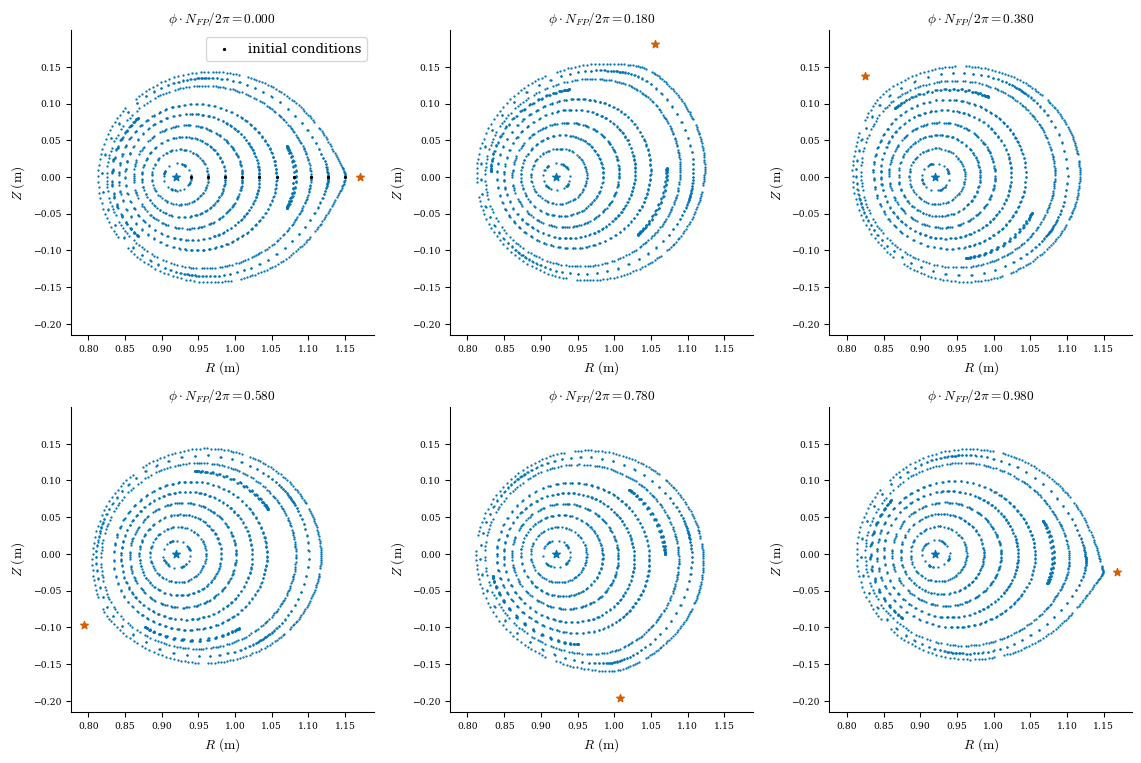

In [88]:
rmaj = 0.97
rmin = 0.2
umbilic_coil = get_umbilic_coil(I=3000, rmaj=rmaj, rmin=rmin)

plasma_coil = FourierRZCoil(current=14000, R_n=R0, Z_n=0)
tf = ToroidalMagneticField(B0=B0, R0=R0)
field = SumMagneticField([plasma_coil, umbilic_coil, tf])
xd = 0.02

N = 10
ntransit = 200
R0is = jnp.linspace(rmaj - 0.03, rmaj + rmin - xd, N)
Z0is = jnp.zeros(N)
Nphi = 50
fig, ax, data = get_poincare_plot(
    field,
    R0is,
    Z0is,
    ntransit,
    phi=Nphi,
    bounds_R=(rmaj - rmin, rmaj + rmin),
    bounds_Z=(-rmin, rmin),
    return_data=True,
    max_steps=50000,
    atol=1e-8,
    rtol=1e-8,
)
add_coils_to_plot(ax, [plasma_coil, umbilic_coil], nplanes=Nphi)
ax.flat[0].scatter(R0is, Z0is, color="black", label="initial conditions", s=2)
ax.flat[0].legend()

# above plot has many phi cuts to compute iota accurately, delete some of
# them for easy read
indices = np.linspace(0, Nphi - 1, 6, dtype=int)
keep_axes = [ax.flat[i] for i in indices]

for a in ax.flat:
    if a not in keep_axes:
        a.remove()

new_gs = plt.GridSpec(2, 3, figure=fig)
for i, a in enumerate(keep_axes):
    a.set_subplotspec(new_gs[i])

fig.set_size_inches(12, 8)
fig.tight_layout()

In [89]:
Mfit = 20
Nfit = 10
surf = get_surface_from_pts(data, M=Mfit, N=Nfit, idx=8, alpha=0)
surf_condensed = get_surface_from_pts(data, M=Mfit, N=Nfit, idx=8, alpha=0.5)

/CODES/DESC/desc/geometry/surface.py:153: UserWarning: Left handed coordinates detected, switching sign of theta. To avoid this warning in the future, switch the sign of all modes with m<0. You may also need to switch the sign of iota or current profiles.
  warnings.warn(
/CODES/DESC/desc/geometry/surface.py:153: UserWarning: Left handed coordinates detected, switching sign of theta. To avoid this warning in the future, switch the sign of all modes with m<0. You may also need to switch the sign of iota or current profiles.
  warnings.warn(


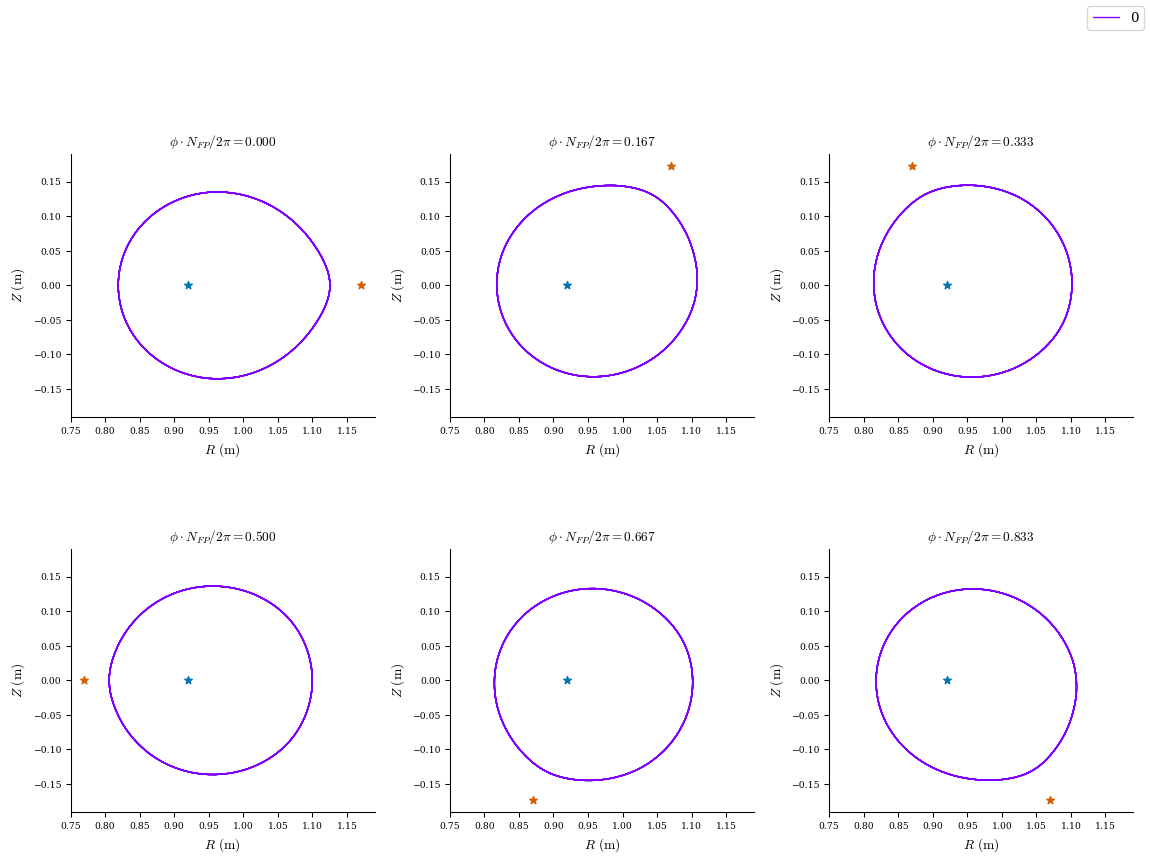

In [90]:
fig, ax = plot_comparison([surf_condensed], theta=0, phi=6)
add_coils_to_plot(ax, [plasma_coil, umbilic_coil], nplanes=6);